In [20]:
import os

from tqdm.notebook import tqdm

import numpy as np
import tifffile
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.special import erf

import kemstem

In [3]:
def calculate_R(raw_data, regressed):
    sse = np.sum(np.square(raw_data - regressed))
    sst = np.sum(np.square(raw_data - raw_data.mean()))
    return 1 - sse/sst

def fit(f, xdata, ydata, plot=False, **kwargs):
    xdata = np.array(xdata).flatten()
    ydata = np.array(ydata).flatten()
    if plot:
        plt.plot(xdata, ydata, 'k.')
        if 'sigma' in kwargs:
            plt.errorbar(xdata, ydata, kwargs['sigma'], fmt='none', c='k')
    popt, pcov = curve_fit(f, xdata, ydata, **kwargs)
    perr = np.sqrt(np.diag(pcov))
    R = calculate_R(ydata, f(xdata, *popt))
    if plot:
        xlim, ylim = plt.xlim(), plt.ylim()
        plt.xlim(*xlim)
        plt.ylim(*ylim)
        x = np.linspace(*xlim, 100)
        plt.plot(x, f(x, *popt), 'r--')
        plt.show()
    return popt, perr, R

In [4]:
# ── .mat 대신 TIF의 phase를 그대로 사용 ────────────────────────────────
# TIF 축 순서는 (Nz, Ny, Nx) → 원본 recons와 동일한 (Ny, Nx, Nz)로 이동
FILES = {
    '2V' : './2V_Niter1000_cropped_phase.tif',
    '5V' : './5V_Niter1000_cropped_phase.tif',
    '8V' : './8V_Niter1000_cropped_phase.tif',
    '30V': './30V_Niter1000_cropped_phase.tif',
}

phases = {}
for key, path in FILES.items():
    stack = tifffile.imread(path)          # (Nz, Ny, Nx), float32, 단위 rad
    phases[key] = np.moveaxis(stack, 0, -1).astype(np.float64)   # (Ny, Nx, Nz)
    print(f'{key:>4s}  {os.path.basename(path)}  →  {phases[key].shape}')

  2V  2V_Niter1000_cropped_phase.tif  →  (288, 288, 20)
  5V  5V_Niter1000_cropped_phase.tif  →  (291, 291, 22)
  8V  8V_Niter1000_cropped_phase.tif  →  (292, 292, 23)
 30V  30V_Niter1000_cropped_phase.tif  →  (272, 272, 31)


In [5]:
# ── slice 두께 dz (Å) ────────────────────────────────────────────────
# .mat의 outputs.z_distance에 해당. TIF에는 이 정보가 담기지 않으므로 직접 지정.
# dz = (전체 두께 T) / (slice 수 NZ)
NLAYERS = {'2V': 20, '5V': 22, '8V': 23, '30V': 31}
THICKNESS = {'2V': 245, '5V': 281, '8V': 336, '30V': 680}   # Å

DZ = {k: THICKNESS[k] / NLAYERS[k] for k in NLAYERS}

for key in phases.keys():
    nz = phases[key].shape[-1]
    assert nz == NLAYERS[key], f'{key}: TIF slice {nz}개 != NLAYERS {NLAYERS[key]}개'
    print(f'{key:>4s}  NZ = {nz:3d}  dz = {DZ[key]:.4f} Å  →  T = {nz*DZ[key]:.2f} Å')

  2V  NZ =  20  dz = 12.2500 Å  →  T = 245.00 Å
  5V  NZ =  22  dz = 12.7727 Å  →  T = 281.00 Å
  8V  NZ =  23  dz = 14.6087 Å  →  T = 336.00 Å
 30V  NZ =  31  dz = 21.9355 Å  →  T = 680.00 Å


In [6]:
column_positions = {}

for key in phases.keys():
    image = phases[key][:, :, phases[key].shape[-1] // 2]
    blurred_image = gaussian_filter(image, 1)
    distance = 2
    threshold = 0.5
    c0 = kemstem.find_columns(blurred_image, distance=distance, threshold=threshold)

    column_positions.update({key: c0})
    print(f'{key:>4s}  {len(c0)} columns')

  2V  379 columns
  5V  396 columns
  8V  404 columns
 30V  384 columns


In [7]:
WINDOW = 1

column_lists = {}

for key in phases.keys():

    c0 = column_positions[key]
    phase = phases[key]                    # 이미 phase 이므로 np.angle 불필요

    column_list = []
    for i, (cx, cy) in enumerate(tqdm(c0)):
        wx_start, wx_end = cx-WINDOW, cx+WINDOW+1
        wy_start, wy_end = cy-WINDOW, cy+WINDOW+1
        column = phase[wx_start:wx_end, wy_start:wy_end, :].mean(axis=(0, 1))
        column_list.append(column)

    column_lists.update({key: column_list})
    print(f'{key:>4s}  {len(column_list)} columns x {len(column_list[0])} slices')

  0%|          | 0/379 [00:00<?, ?it/s]

  2V  379 columns x 20 slices


  0%|          | 0/396 [00:00<?, ?it/s]

  5V  396 columns x 22 slices


  0%|          | 0/404 [00:00<?, ?it/s]

  8V  404 columns x 23 slices


  0%|          | 0/384 [00:00<?, ?it/s]

 30V  384 columns x 31 slices


In [24]:
gaussian = lambda x, mu, sig : norm.pdf(x, loc=mu, scale=sig)
double_erf = lambda x, p, q, x0, x1 : p * (erf(q*(x - x0)) - erf(q*(x - x1)))
double_erf_plus_const = lambda x, p0, p1, q, x0, x1: p0 + double_erf(x, p1, q, x0, x1)

In [9]:
crystalline_heights = {}
crystalline_height_errs = {}
interface_tops = {}
interface_bots = {}

for key in phases.keys():

    columns = column_lists[key]
    dz = DZ[key]

    crystalline = []
    crystalline_err = []
    z_tops = []
    z_bots = []

    for column in tqdm(columns):
        popt, perr, _ = fit(
            double_erf, np.arange(len(column)), column, plot=False,
            p0=[0.1,  0.3,  3, 12],
            # bounds=bounds,
            maxfev=10000
            )
        p1, q, x0, x1 = popt
        dp1, dq, dx0, dx1 = perr

        crystalline.append((x1 - x0) * dz)
        crystalline_err.append(dz * (dx0 + dx1) / 2)
        z_tops.append((x0 + 0.5) * dz)
        z_bots.append((x1 + 0.5) * dz)

    crystalline_heights.update({key: np.array(crystalline)})
    crystalline_height_errs.update({key: np.array(crystalline_err)})
    interface_tops.update({key: np.array(z_tops)})
    interface_bots.update({key: np.array(z_bots)})

  0%|          | 0/379 [00:00<?, ?it/s]

  0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/384 [00:00<?, ?it/s]

In [10]:
safe_height_indices = {}

for key in phases.keys():
    crystalline = crystalline_heights[key]
    crystalline_err = crystalline_height_errs[key]

    # 이상치 제거 없음. 물리적으로 불가능한 값만 배제
    safe_height_index = np.where(np.isfinite(crystalline) & (crystalline > 0))
    safe_height_indices.update({key: safe_height_index})

In [11]:
for key, phase in phases.items():
    print(key)
    print(phase.shape[:-1])
    print([(phase.shape[0] * i) // 8 for i in [1, 3, 5, 7]])

2V
(288, 288)
[36, 108, 180, 252]
5V
(291, 291)
[36, 109, 181, 254]
8V
(292, 292)
[36, 109, 182, 255]
30V
(272, 272)
[34, 102, 170, 238]


In [12]:
# ── thickness ROI: 중앙 1/4 크기 (각 축 1/4 → 3/4 지점) ────────────────
thickness_rois = {}

for key in phases.keys():
    ny, nx = phases[key].shape[:2]
    x0, x1 = nx // 4, nx - nx // 4       # 열(가로) 방향
    y0, y1 = ny // 4, ny - ny // 4       # 행(세로) 방향
    thickness_rois[key] = [[x0, x1], [y0, y1]]
    print(f'{key:>4s}  image {ny}x{nx}  →  x [{x0}, {x1}]  y [{y0}, {y1}]  '
          f'({x1-x0} x {y1-y0} px)')

  2V  image 288x288  →  x [72, 216]  y [72, 216]  (144 x 144 px)
  5V  image 291x291  →  x [72, 219]  y [72, 219]  (147 x 147 px)
  8V  image 292x292  →  x [73, 219]  y [73, 219]  (146 x 146 px)
 30V  image 272x272  →  x [68, 204]  y [68, 204]  (136 x 136 px)


In [13]:
ROI_SIZE = 23.04        # Å, 모든 thickness ROI 한 변 (가정)

DX = {}
for k, ((x0, x1), (y0, y1)) in thickness_rois.items():
    npx = ((x1 - x0) + (y1 - y0)) / 2      # 정사각형 가정, 두 변 평균
    DX[k] = ROI_SIZE / npx
    print(f'{k:>4s}  ROI {x1-x0} x {y1-y0} px  →  {DX[k]:.5f} Å/px')

  2V  ROI 144 x 144 px  →  0.16000 Å/px
  5V  ROI 147 x 147 px  →  0.15673 Å/px
  8V  ROI 146 x 146 px  →  0.15781 Å/px
 30V  ROI 136 x 136 px  →  0.16941 Å/px


In [14]:
roi_indices = {}

for key in phases.keys():
    c0 = column_positions[key]
    indices = []
    (x0, x1), (y0, y1) = thickness_rois[key]
    idx = np.where(
        (c0[:,0] >= y0) & (c0[:,0] <= y1) & (c0[:,1] >= x0) & (c0[:,1] <= x1)
    )
    indices.append(idx)
    roi_indices.update({key: indices})

In [15]:
roi_crystalline_height_means = {}
roi_crystalline_height_stds = {}
roi_amorphous_height_means = {}
roi_amorphous_height_stds = {}

for key in phases.keys():

    safe_idx = safe_height_indices[key]
    roi_idx = roi_indices[key]
    total_thickness = phases[key].shape[-1] * DZ[key]

    idx = np.intersect1d(safe_idx, roi_idx)

    height = crystalline_heights[key]

    crystalline_mean = height[idx].mean()
    crystalline_std = height[idx].std()
    amorphous_mean = (total_thickness - crystalline_mean) / 2
    amorphous_std = crystalline_std / 2

    roi_crystalline_height_means.update({key: crystalline_mean})
    roi_crystalline_height_stds.update({key: crystalline_std})
    roi_amorphous_height_means.update({key: amorphous_mean})
    roi_amorphous_height_stds.update({key: amorphous_std})

    # --- 상/하 비정질을 따로 (대칭 가정 검증용) ---
    a_top = interface_tops[key][idx]
    a_bot = total_thickness - interface_bots[key][idx]

    print(f'{key:>4s}  n = {len(idx)}/{len(roi_idx[0][0])}   T = {total_thickness:.1f} Å')
    print(f'      crystalline : {crystalline_mean:7.2f} ± {crystalline_std:5.2f}')
    print(f'      amorphous   : {amorphous_mean:7.2f} ± {amorphous_std:5.2f}  (대칭 가정)')
    print(f'      상부 {a_top.mean():6.2f} ± {a_top.std():5.2f}  |  '
          f'하부 {a_bot.mean():6.2f} ± {a_bot.std():5.2f}   '
          f'비대칭 {a_top.mean()-a_bot.mean():+6.2f} Å')

  2V  n = 102/102   T = 245.0 Å
      crystalline :  177.58 ± 24.80
      amorphous   :   33.71 ± 12.40  (대칭 가정)
      상부  37.12 ± 13.03  |  하부  30.30 ± 13.40   비대칭  +6.82 Å
  5V  n = 102/102   T = 281.0 Å
      crystalline :  180.83 ±  8.48
      amorphous   :   50.08 ±  4.24  (대칭 가정)
      상부  51.74 ±  6.51  |  하부  48.43 ±  5.01   비대칭  +3.31 Å
  8V  n = 118/118   T = 336.0 Å
      crystalline :  195.31 ± 10.09
      amorphous   :   70.34 ±  5.04  (대칭 가정)
      상부  68.72 ±  6.36  |  하부  71.96 ±  5.61   비대칭  -3.24 Å
 30V  n = 102/102   T = 680.0 Å
      crystalline :  134.23 ± 49.86
      amorphous   :  272.88 ± 24.93  (대칭 가정)
      상부 276.40 ± 23.03  |  하부 269.36 ± 28.57   비대칭  +7.04 Å


2V
Crystalline thickness: 177.575 ± 24.796
Amorphous thickness:    33.712 ±  12.398
(# of counted columns = 102/102)


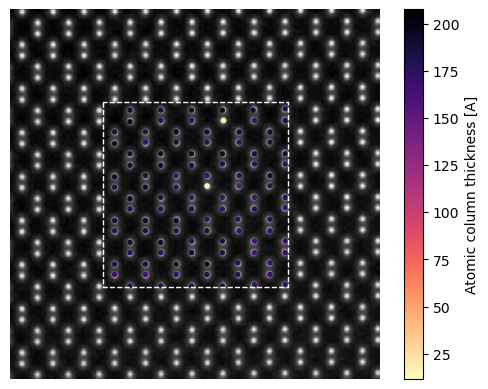

5V
Crystalline thickness: 180.830 ± 8.477
Amorphous thickness:    50.085 ±  4.239
(# of counted columns = 102/102)


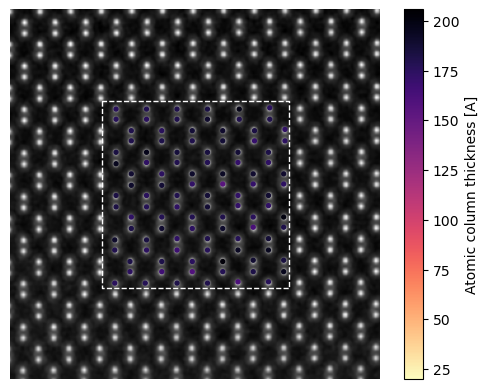

8V
Crystalline thickness: 195.313 ± 10.086
Amorphous thickness:    70.343 ±  5.043
(# of counted columns = 118/118)


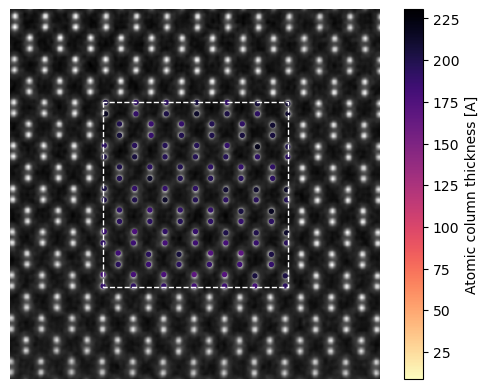

30V
Crystalline thickness: 134.232 ± 49.856
Amorphous thickness:    272.884 ±  24.928
(# of counted columns = 102/102)


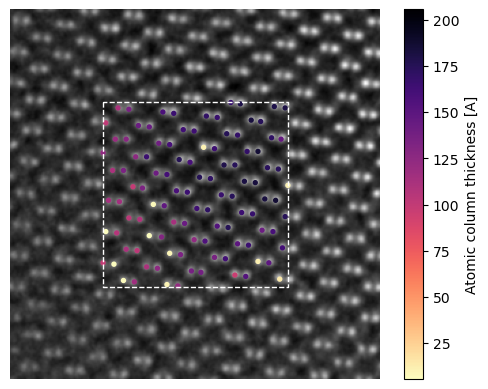

In [16]:
for key in phases.keys():

    phase = phases[key]
    heights = crystalline_heights[key]
    c0 = column_positions[key]

    crystalline_mean = roi_crystalline_height_means[key]
    crystalline_std = roi_crystalline_height_stds[key]
    amorphous_mean = roi_amorphous_height_means[key]
    amorphous_std = roi_amorphous_height_stds[key]


    safe_idx = safe_height_indices[key]
    roi_idx = roi_indices[key]
    idx = np.intersect1d(safe_idx, roi_idx)

    print(key)
    print(f"Crystalline thickness: {crystalline_mean:.3f} ± {crystalline_std:.3f}")
    print(f"Amorphous thickness:    {amorphous_mean:.3f} ±  {amorphous_std:.3f}")
    print(f"(# of counted columns = {len(idx)}/{len(roi_idx[0][0])})")

    (x0, x1), (y0, y1) = thickness_rois[key]
    plt.imshow(phase.sum(axis=-1), cmap='gray')
    plt.plot([x0, x0, x1, x1, x0], [y0, y1, y1, y0, y0], lw=1, color='white', linestyle='--')

    plt.axis('off')
    plt.scatter(
        c0[:, 1][idx], c0[:, 0][idx], c=np.array(heights)[idx], s=8, cmap='magma_r',
        vmin=heights[safe_idx].min(),
        vmax=heights[safe_idx].max()
        )
    cbar = plt.colorbar()
    cbar.ax.set_ylabel('Atomic column thickness [A]')
    plt.show()

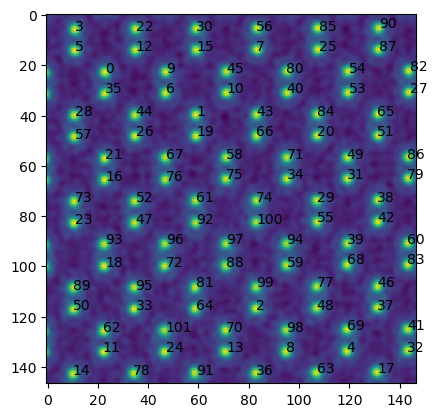

In [21]:
key = '5V'
roi = thickness_rois[key]
(xi, xf), (yi, yf) = roi
phase = phases[key][yi:yf, xi:xf]


img_roi = phase[:, :, phase.shape[-1]//2]

cols = column_positions[key][roi_indices[key][0][0]]
cx, cy = cols.T
cx -= yi
cy -= xi


plt.imshow(img_roi)
for i in range(len(cx)):
    plt.text(cy[i], cx[i], str(i))

# plt.plot(*cols[43].T[::-1], 'r.')

In [22]:
# #  block for analysing divergent regressions
# idx = np.where(crystalline_height_errs[key][roi_indices[key]] > crystalline_heights[key][roi_indices[key]] / 10)[0]

# for i in idx[::]:
#     c = column_lists[key][i]
#     z = np.arange(len(c)) * DZ[key]

#     popt, perr, _ = fit(
#         double_erf, np.arange(len(c)), c, plot=True,
#         p0=[[0.1,  0.3,  3, 12]],
#         # bounds=bounds,
#         maxfev=10000
#         )

#     p1, q, x0, x1 = popt
#     dp1, dq, dx0, dx1 = perr

#     print(f"Column index: {i}")
#     print(f"Thickness: {(x1 - x0) * dz:.2f}, Error: {dz * (dx0 + dx1) / 2:.2f}, Ratio: {(dz * (dx0 + dx1) / 2) /  (x1 - x0) * dz:.2f}")

#     plt.show()

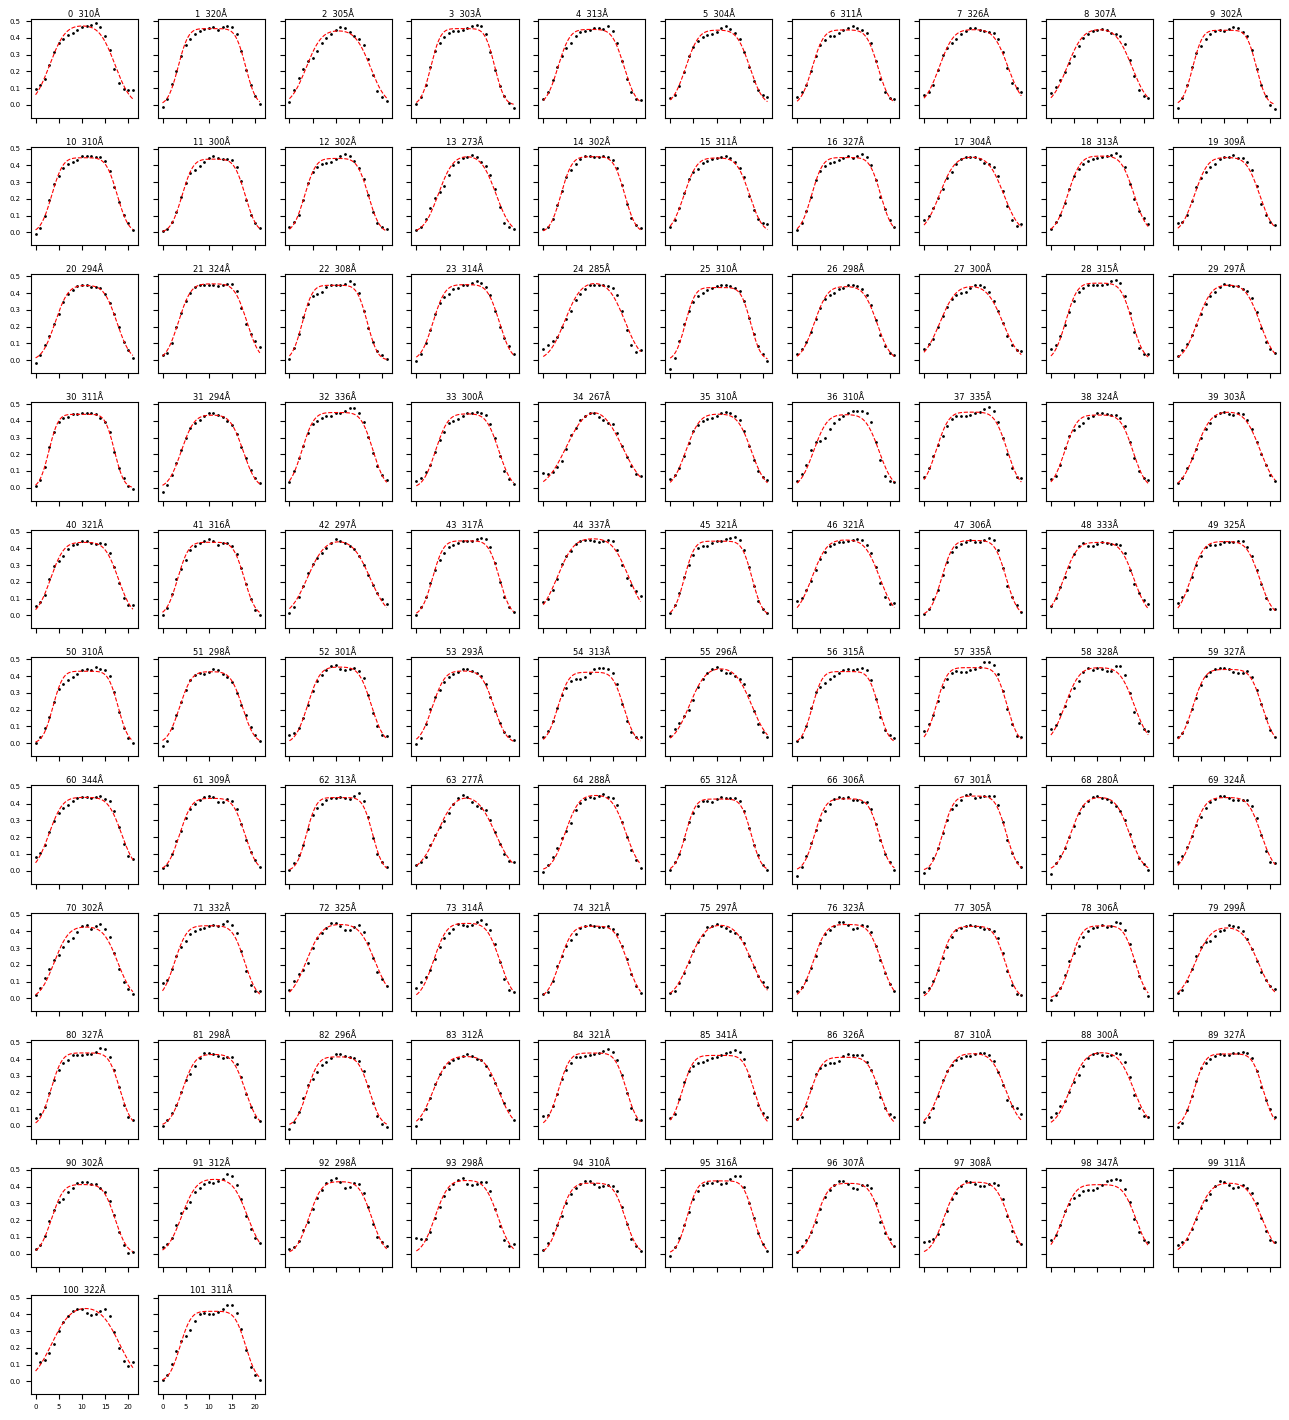

In [25]:
idx = roi_indices[key][0][0]

NCOL = 10
nrow = int(np.ceil(len(idx) / NCOL))
fig, axes = plt.subplots(nrow, NCOL, figsize=(NCOL*1.3, nrow*1.3),
                         sharex=True, sharey=True)
axes = axes.ravel()

for n, i in enumerate(idx):
    ax = axes[n]
    c = column_lists[key][i]
    z = np.arange(len(c)) * DZ[key]

    popt, perr, _ = fit(
        double_erf, np.arange(len(c)), c, plot=False,
        p0=[[0.1,  0.3,  3, 12]],
        # bounds=bounds,
        maxfev=10000
        )

    p1, q, x0, x1 = popt
    dp1, dq, dx0, dx1 = perr

    t = np.linspace(0, len(c)-1, 200)
    ax.plot(np.arange(len(c)), c, 'k.', ms=2)
    ax.plot(t, double_erf(t, *popt), 'r--', lw=0.8)
    ax.set_title(f"{n}  {(x1 - x0) * dz:.0f}Å", fontsize=6, pad=1)
    ax.tick_params(labelsize=5)

for ax in axes[len(idx):]:
    ax.axis('off')

fig.tight_layout()
plt.show()

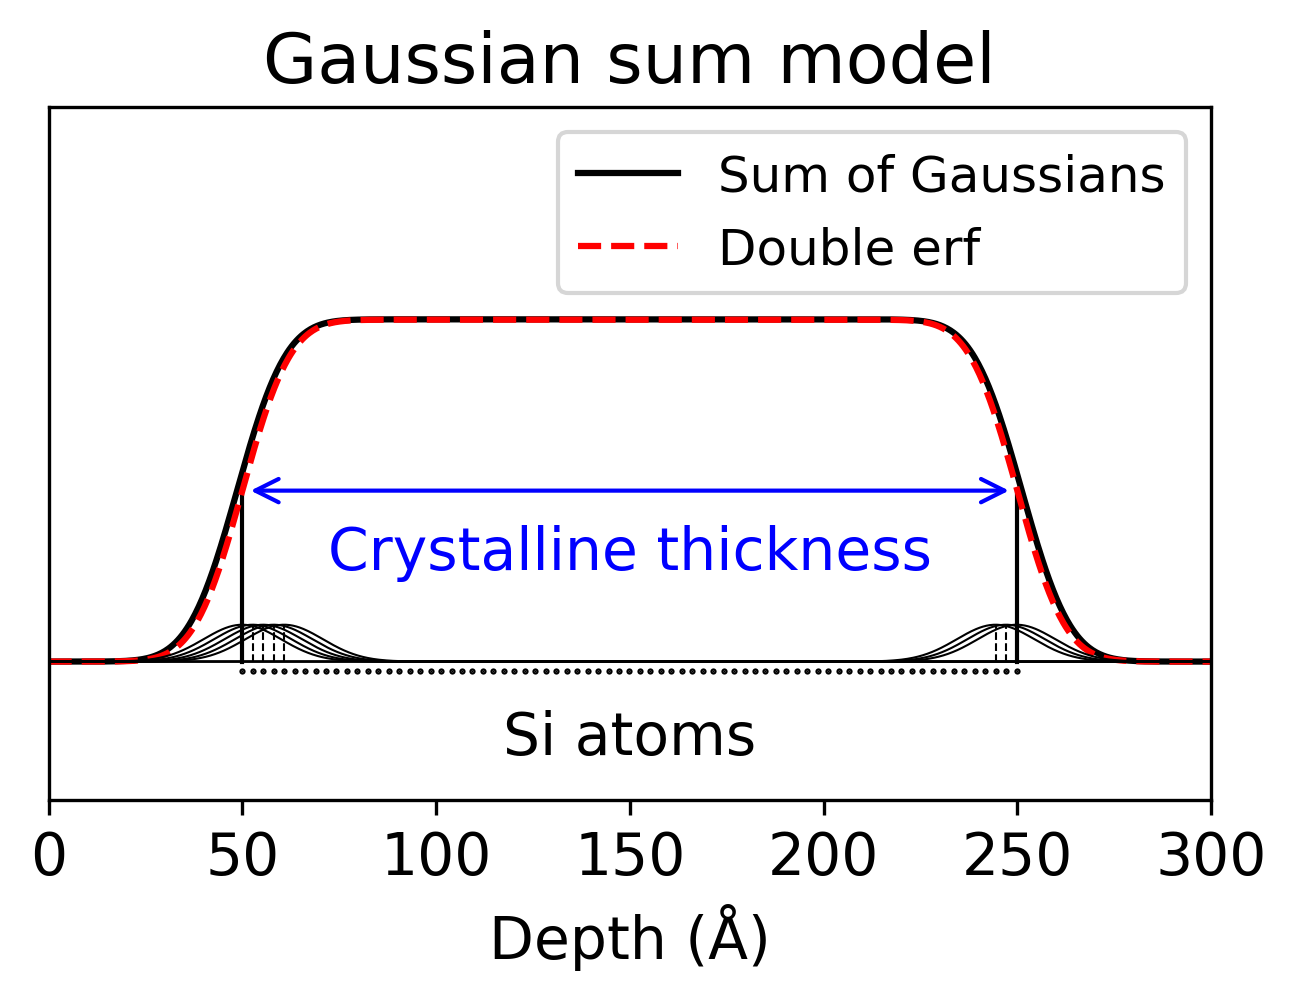

In [21]:
x = np.linspace(0, 300, 1000)
ps = np.arange(50, 250+0.1, 2.7)
ys = []
for p in ps:
    y = gaussian(x, p, 10)
    ys.append(y)
ys = np.array(ys)
Y = ys.sum(axis=0)

# fig, axs = plt.subplots(2, 2, figsize=(10, 7), dpi=300)

plt.figure(figsize=(5, 3), dpi=300)
plt.xlim(0, 300)
plt.ylim(-0.15, 0.6)
plt.plot(x, Y, 'k-', label="Sum of Gaussians")
plt.plot([50, 50], [0, 0.185], 'k-', lw=1)
plt.plot([250, 250], [0, 0.185],  'k-', lw=1)
plt.plot(x, double_erf(x, 0.185, 0.072, 50, 250), 'r--', label="Double erf")
for i in [0, 1, 2, 3, 4, -3, -2, -1]:
    plt.plot(x, ys[i], 'k-', lw=.5)
    plt.plot([ps[i]]*2, [0, ys[i].max()], 'k--', lw=.5)
plt.plot(ps, np.ones_like(ps)*(-0.01), 'k.', markersize=1)
plt.text(150, -0.1, "Si atoms", ha='center')
plt.annotate(
    "",                      # Leave text blank to only show the arrow
    xy=(50, 0.185),               # Head position 1 (x, y)
    xytext=(250, 0.185),           # Head position 2 (x, y)
    arrowprops=dict(
        arrowstyle="<->",    # Creates the double head
        color="blue",        # Arrow color
        lw=1                 # Line width
    )
)
plt.text(150, 0.1, "Crystalline thickness", ha='center', color='blue')

# plt.set_xticks([])
plt.yticks([])
plt.xlabel("Depth (Å)")
plt.title("Gaussian sum model")
plt.legend(fontsize=12)

plt.show()


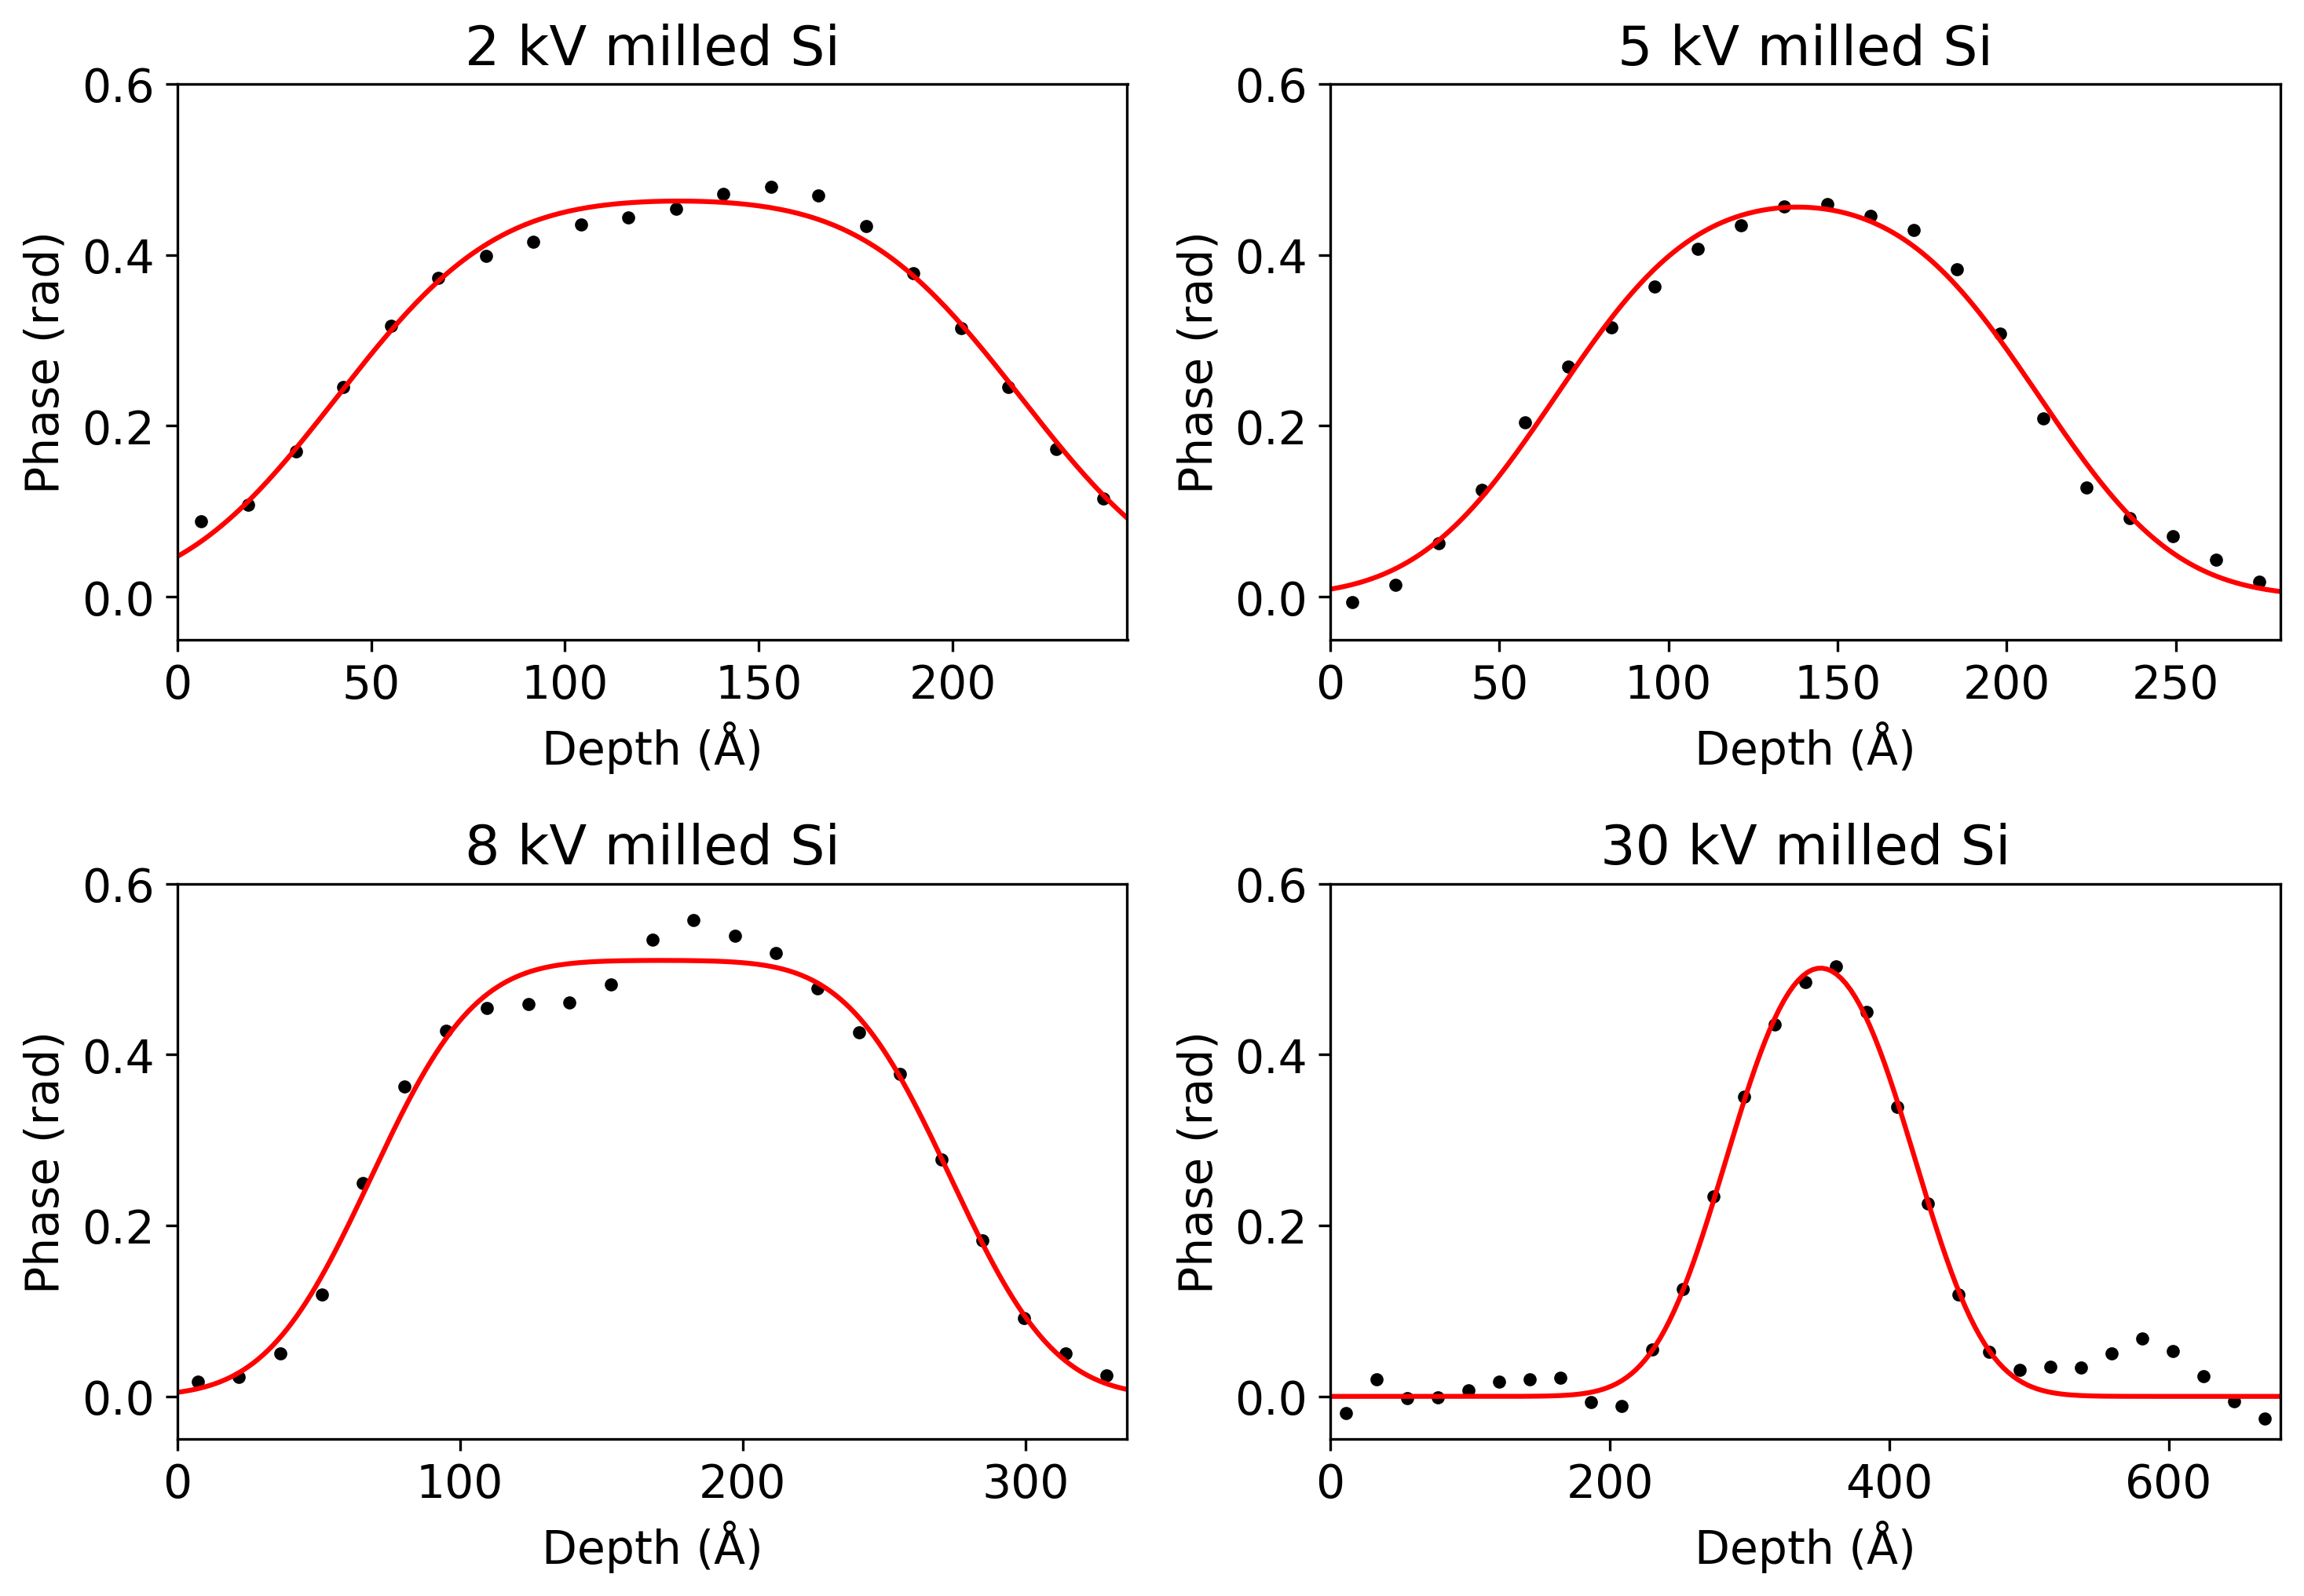

In [22]:
x = np.linspace(0, 300, 1000)
ps = np.arange(50, 250+0.1, 2.7)
ys = []
for p in ps:
    y = gaussian(x, p, 5)
    ys.append(y)
ys = np.array(ys)
Y = ys.sum(axis=0)

fig, axs = plt.subplots(2, 2, figsize=(10, 7), dpi=300)

keys = ['2V', '5V', '8V', '30V']

for i in range(4):
    ax = axs.flatten()[i]
    key = keys[i]
    dz = DZ[key]
    c = column_lists[key][72]
    z = np.arange(len(c)) * dz
    popt, perr, _ = fit(double_erf, np.arange(len(c)), c, plot=False, p0=[[0.1,  0.3,  3, 12]],maxfev=10000)
    ax.plot(z + dz/ 2, c, 'k.')
    xlim = (0, z[-1] + dz)
    ax.set_xlim(xlim)
    t = np.linspace(*xlim, 200)
    ax.plot(t, double_erf((t - dz/2) / dz, *popt), 'r-')
    ax.set_title(f"{key[:-1]} kV milled Si")
    ax.set_xlabel("Depth (Å)")
    ax.set_ylabel("Phase (rad)")
    ax.set_ylim(-0.05, 0.6)

fig.tight_layout()
plt.show()


In [ ]:
plt.

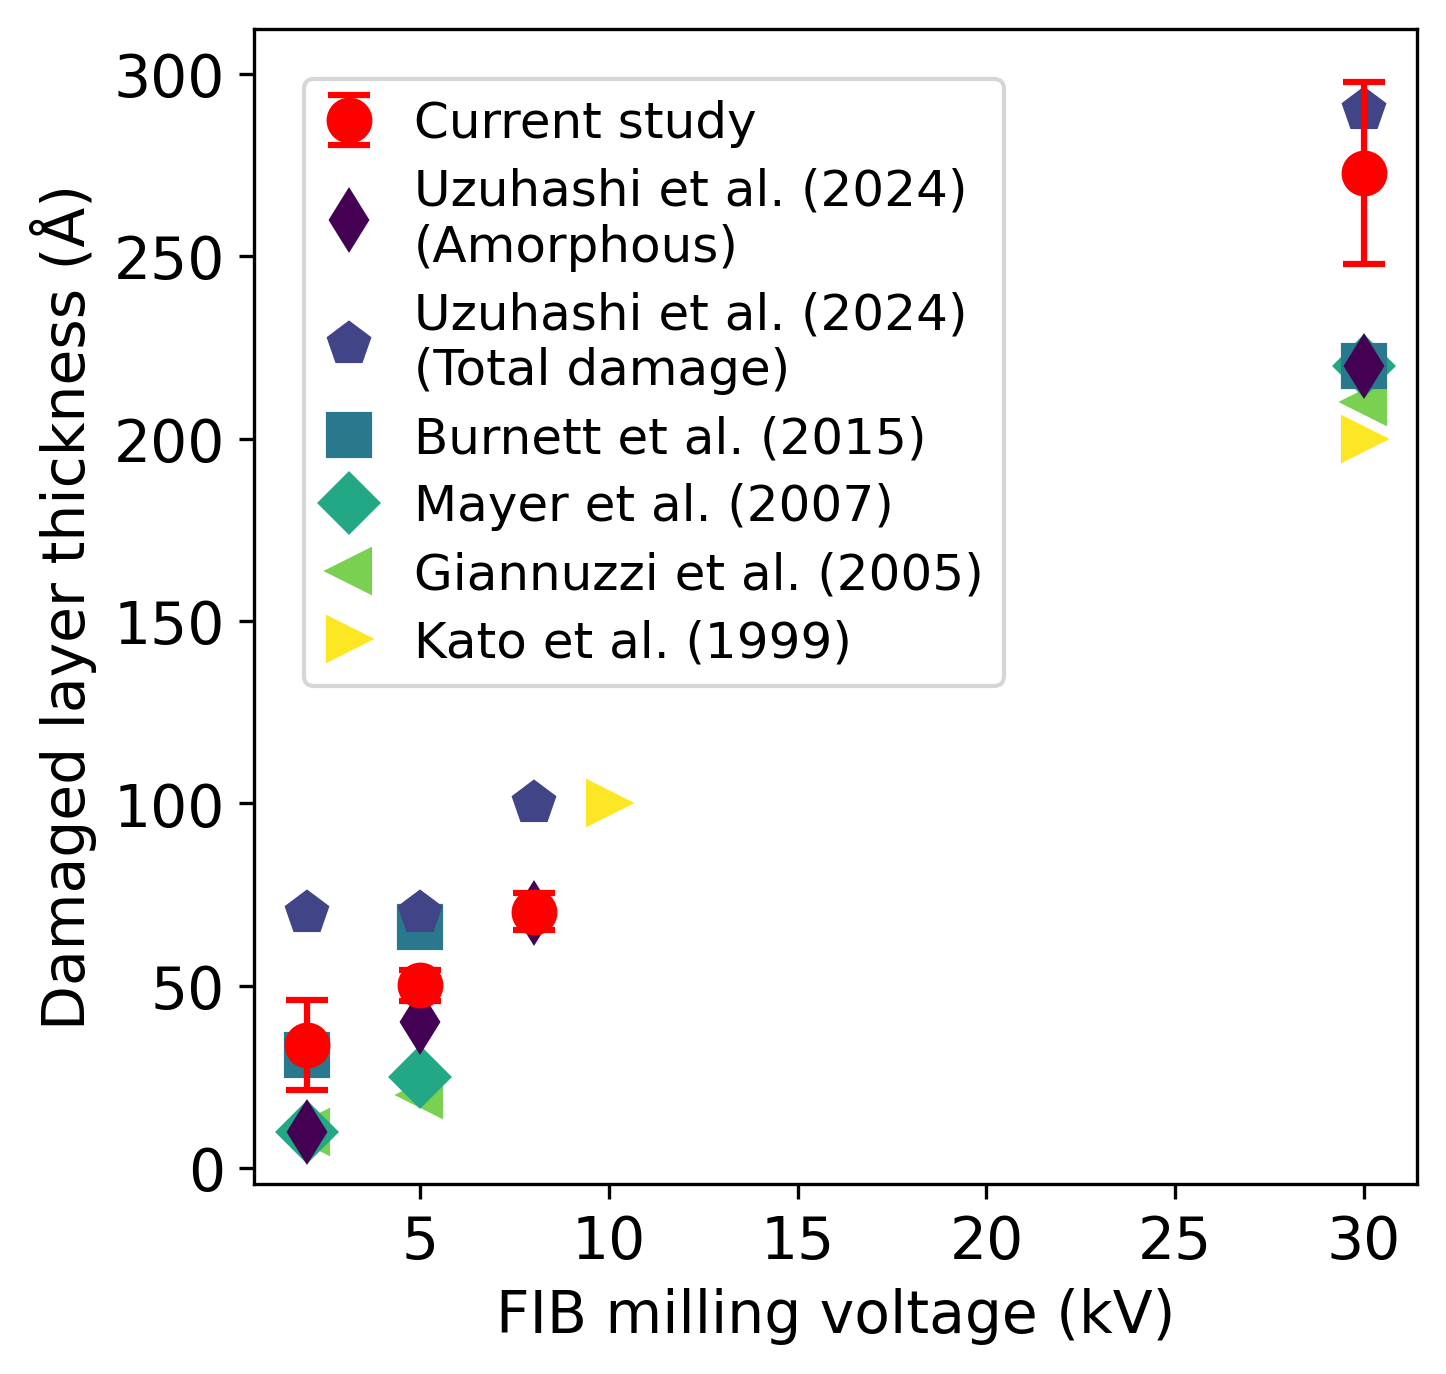

In [31]:
voltages = []
damage = []
damage_err = []

for key in phases.keys():
    voltages.append(float(key[:-1]))
    damage.append(roi_amorphous_height_means[key])
    damage_err.append(roi_amorphous_height_stds[key])

literature = [
    ([30, 8, 5, 2], [220, 70, 40, 10],  'd', 'Uzuhashi et al. (2024)\n(Amorphous)'),
    ([30, 8, 5, 2], [290, 100, 70, 70], 'p', 'Uzuhashi et al. (2024)\n(Total damage)'),
    ([30, 5, 2],    [220, 66, 31],      's', 'Burnett et al. (2015)'),
    ([30, 5, 2],    [220, 25, 10],      'D', 'Mayer et al. (2007)'),
    ([30, 5, 2],    [210, 20, 10],      '<', 'Giannuzzi et al. (2005)'),
    ([30, 10],      [200, 100],         '>', 'Kato et al. (1999)'),
]

# plot_colors = [
#     'red',
#     'tab:blue',
#     'tab:orange',
#     'tab:green',
#     'tab:brown',
#     'tab:pink',
#     'tab:gray',
#     'tab:olive',
#     'tab:cyan',
# ]
MARKERSIZE=10

plt.figure(figsize=(5, 5), dpi=300)

ZTOP = 100
handles = []

eb = plt.errorbar(voltages, damage, damage_err,
    fmt="o", capsize=5, capthick=1.5, elinewidth=1.5, label="Current study", markersize=MARKERSIZE,
    zorder=ZTOP, color='red'
    )
handles.append(eb)

for i, (v, d, mk, lab) in enumerate(literature):
    ln, = plt.plot(v, d, mk, label=lab, zorder=ZTOP - 1 - i, color=plt.colormaps['viridis'](i / 5), markersize=MARKERSIZE)
    handles.append(ln)

plt.xlabel("FIB milling voltage (kV)", fontsize=14)
plt.ylabel("Damaged layer thickness (Å)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(handles=handles, fontsize=12,
           labelspacing=0.4,     # 항목 간 세로 간격 (기본 0.5)
           handlelength=1.0,      # 핸들 가로 길이 (기본 2.0) — 마커라 길 필요 없음
           handletextpad=0.8,     # 핸들↔텍스트 (기본 0.8)
           borderpad=0.4,         # 테두리 안쪽 여백 (기본 0.4)
           borderaxespad=1,     # 테두리↔축 (기본 0.5)
           frameon=True)         # 테두리 제거 (선택)
plt.show()

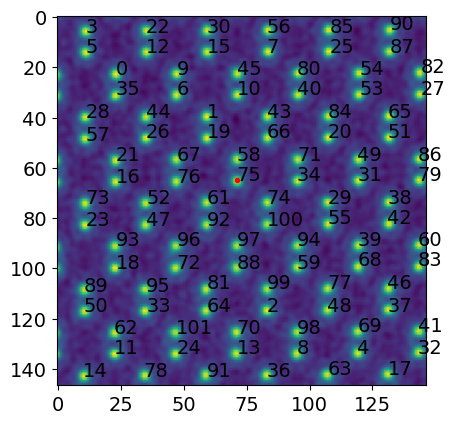

In [24]:
key = '5V'
roi = thickness_rois[key]
(xi, xf), (yi, yf) = roi
phase = phases[key][yi:yf, xi:xf]


img_roi = phase[:, :, phase.shape[-1]//2]

cols = column_positions[key][roi_indices[key][0][0]]
cx, cy = cols.T
cx -= yi
cy -= xi


plt.imshow(img_roi)
for i in range(len(cx)):
    plt.text(cy[i], cx[i], str(i))

plt.plot(*cols[75].T[::-1], 'r.')

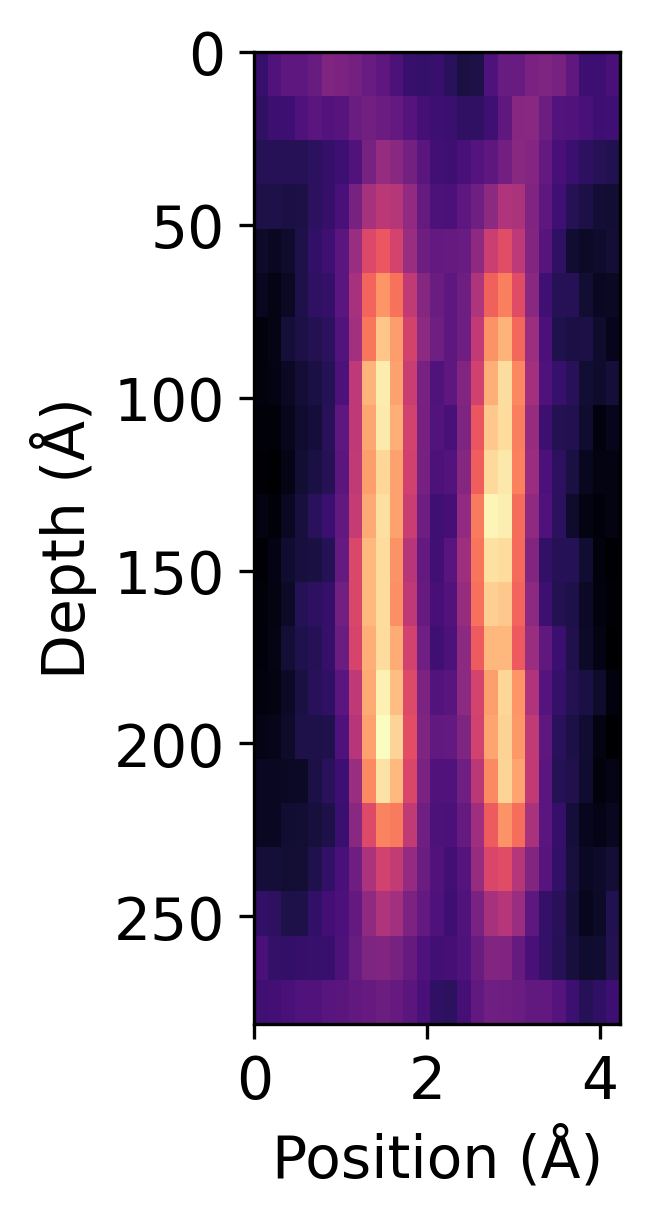

In [25]:
from scipy.ndimage import map_coordinates
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

key       = '5V'
PICK      = 43
FIGSIZE   = (2, 4)
DPI       = 300
FONT      = 14
AXES_RECT = [0.36, 0.16, 0.61, 0.81]   # ← 두 셀 공통. 좌우 정렬의 핵심

(xi, xf), (yi, yf) = thickness_rois[key]
dz = DZ[key]
dx = DX[key]
NZ = phases[key].shape[-1]
T  = NZ * dz

arr = phases[key][yi:yf, xi:xf]

x1, x2 = 70, 70      # 열 (고정)  ← ROI 좌표계. 새 ROI 크기에 맞춰 확인 필요
y1, y2 = 48, 74     # 행 (범위)

n = int(np.hypot(x2 - x1, y2 - y1)) + 1
L = n * dx           # 픽셀 셀 폭 기준 (깊이축 T = NZ*dz와 같은 규약)

y_line = np.linspace(x1, x2, n)
x_line = np.linspace(y1, y2, n)
z = np.arange(NZ)

xx, zz = np.meshgrid(x_line, z, indexing="xy")
yy, _  = np.meshgrid(y_line, z, indexing="xy")

cross_section = map_coordinates(arr, [xx, yy, zz], order=1, mode="nearest")

fig = plt.figure(figsize=FIGSIZE, dpi=DPI)
ax  = fig.add_axes(AXES_RECT)
ax.imshow(cross_section, aspect="auto", cmap='magma', extent=[0, L, T, 0])
ax.set_xlabel("Position (Å)", fontsize=FONT)
ax.set_ylabel("Depth (Å)", fontsize=FONT)
ax.xaxis.set_major_locator(MaxNLocator(nbins=3, integer=True))
ax.tick_params(labelsize=FONT)
plt.show()

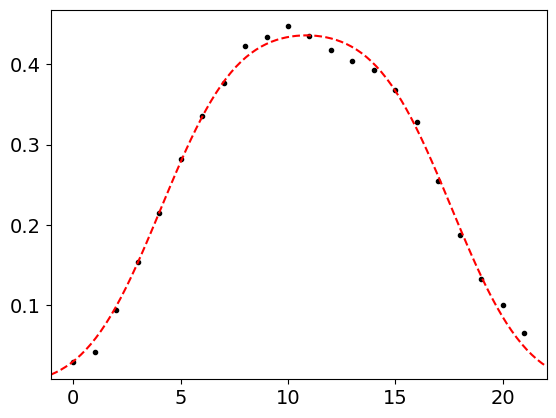

5V  NZ=22  dz=12.7727 Å  T=281.00 Å
ROI #75 = 전체 #306, 위치 [137 143]
  x0=4.09, x1=17.62
  상부  58.64 | 결정질 172.79 | 하부  49.56 Å   (합 281.00)


In [26]:
key  = '5V'                      # ← 이 셀에서 확정
PICK = 75

dz = DZ[key]                     # key로부터 매번 다시 계산 (캐시 안 씀)
NZ = phases[key].shape[-1]
T  = NZ * dz

roi_ids = roi_indices[key][0][0]
gid     = roi_ids[PICK]

y = np.asarray(column_lists[key])[gid]
x = np.arange(len(y))            # 인덱스 k = slice k

assert len(y) == NZ, f'{key}: 프로파일 {len(y)}점 != 슬라이스 {NZ}개'

popt, perr, _ = fit(
    double_erf, x, y, plot=True,
    p0=[0.1,  0.3,  4, 13],      # ← Cell 7과 반드시 동일하게 유지
    # bounds=bounds,
    maxfev=10000
    )

z_top = (popt[2] + 0.5) * dz
z_bot = (popt[3] + 0.5) * dz

print(f'{key}  NZ={NZ}  dz={dz:.4f} Å  T={T:.2f} Å')
print(f'ROI #{PICK} = 전체 #{gid}, 위치 {column_positions[key][gid]}')
print(f'  x0={popt[2]:.2f}, x1={popt[3]:.2f}')
print(f'  상부 {z_top:6.2f} | 결정질 {z_bot - z_top:6.2f} | 하부 {T - z_bot:6.2f} Å'
      f'   (합 {T:.2f})')

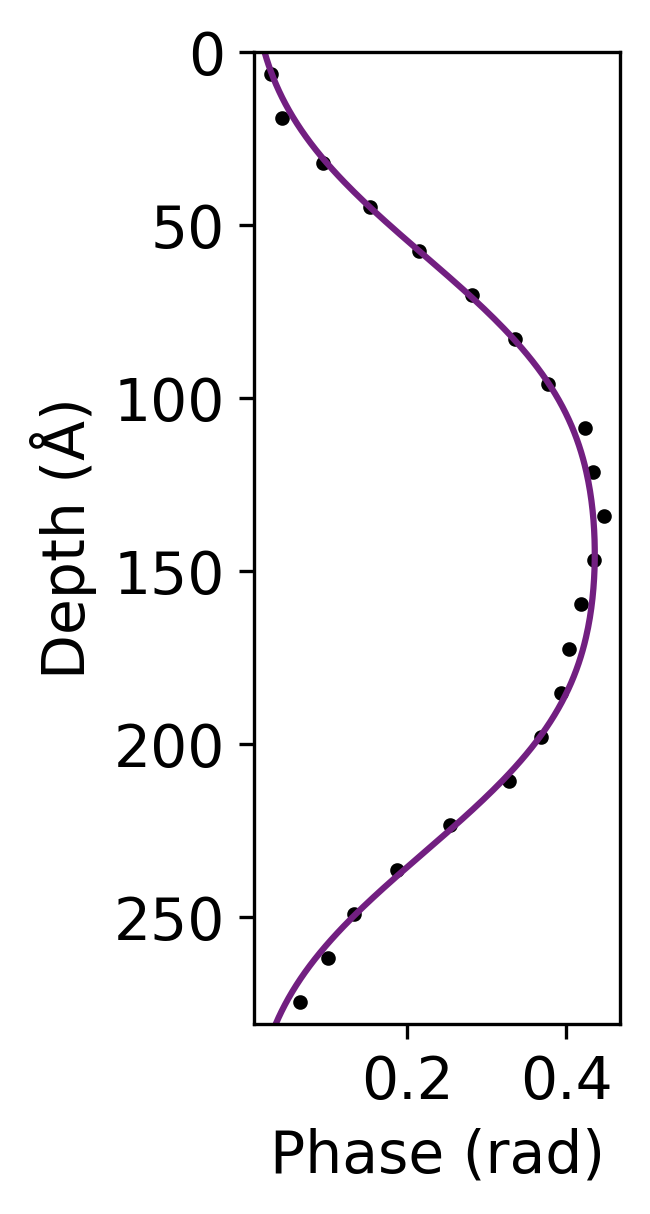

In [27]:
depth = (x + 0.5) * dz               # slice 중심

fig = plt.figure(figsize=FIGSIZE, dpi=DPI)
ax  = fig.add_axes(AXES_RECT)        # ← 위 셀과 동일

ax.plot(y, depth, 'k.', ms=5)
xlim = ax.get_xlim()

t = np.linspace(-0.5, NZ - 0.5, 300)
ax.plot(double_erf(t, *popt), (t + 0.5) * dz,
        color=plt.cm.magma(1/3), lw=1.5)

ax.set_xlim(xlim)
ax.set_ylim(T, 0)
ax.set_xlabel("Phase (rad)", fontsize=FONT)
ax.set_ylabel("Depth (Å)", fontsize=FONT)
ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.tick_params(labelsize=FONT)
plt.show()

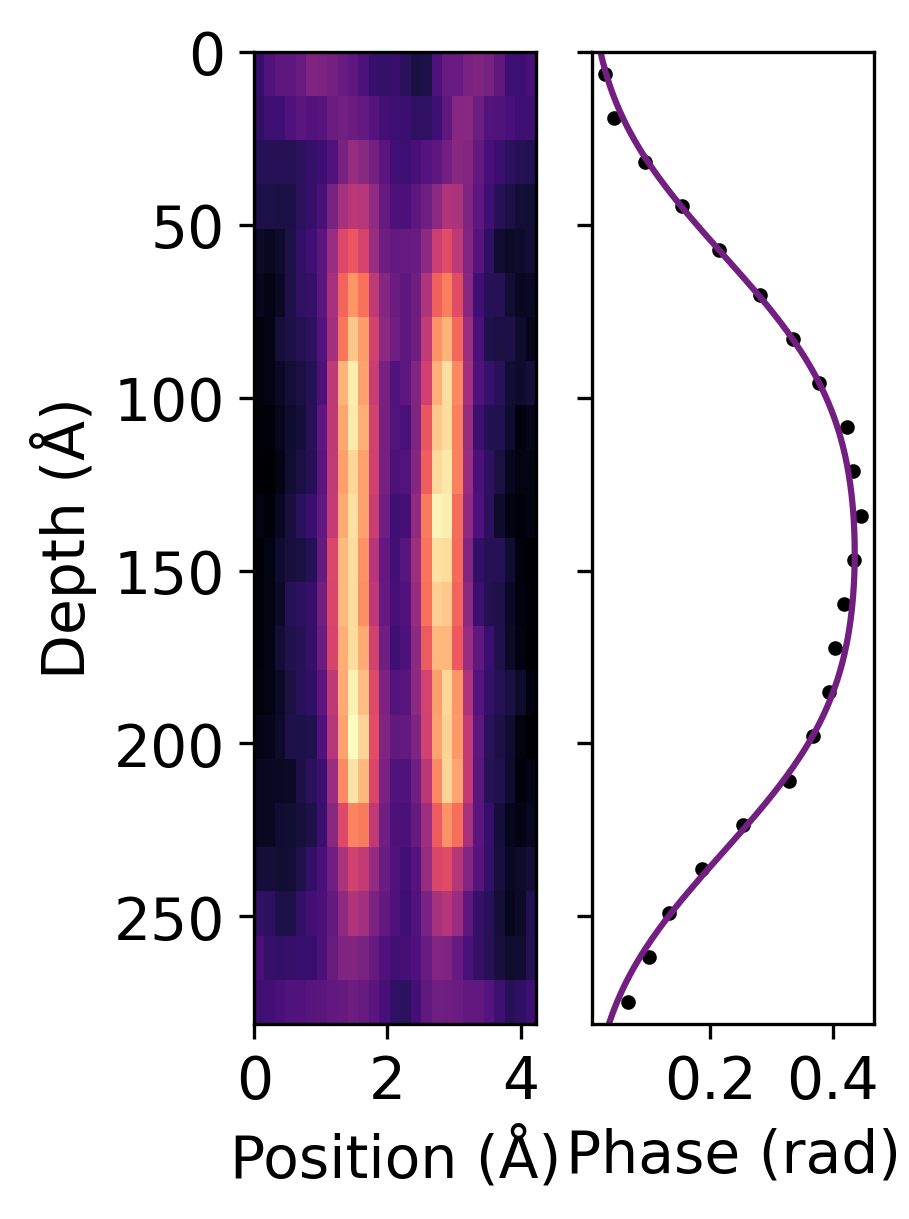

In [28]:
# ── 좌: 단면(cross-section) / 우: column phase profile — Depth 축 공유 ──
KEY   = '5V'
PICK  = 75

FIGSIZE2  = (2.6, 4)          # 좌우 2패널이므로 폭만 2배
WSPACE    = 0.2
MARGIN    = dict(left=0.19, right=0.985, bottom=0.16, top=0.97)

LINE_COL  = 70              # 열 (고정)   ← ROI 좌표계
LINE_ROW  = (48, 74)        # 행 (범위)

dz = DZ[KEY]
dx = DX[KEY]
NZ = phases[KEY].shape[-1]
T  = NZ * dz

# ── 좌패널 데이터: 단면 재계산 ─────────────────────────────────────
(xi, xf), (yi, yf) = thickness_rois[KEY]
arr = phases[KEY][yi:yf, xi:xf]

r0, r1 = LINE_ROW
n = int(np.hypot(0, r1 - r0)) + 1
L = n * dx

col_line = np.linspace(LINE_COL, LINE_COL, n)
row_line = np.linspace(r0, r1, n)
zs = np.arange(NZ)

rr, zz = np.meshgrid(row_line, zs, indexing="xy")
cc, _  = np.meshgrid(col_line, zs, indexing="xy")

cross_section = map_coordinates(arr, [rr, cc, zz], order=1, mode="nearest")

# ── 우패널 데이터: 단일 column fit 재계산 ──────────────────────────
gid  = roi_indices[KEY][0][0][PICK]
prof = np.asarray(column_lists[KEY])[gid]
k    = np.arange(len(prof))

assert len(prof) == NZ, f'{KEY}: 프로파일 {len(prof)}점 != 슬라이스 {NZ}개'

popt_c, perr_c, _ = fit(
    double_erf, k, prof, plot=False,
    p0=[0.1,  0.3,  4, 13],      # ← Cell 7 / 22와 동일하게 유지
    maxfev=10000
    )

# ── 작도 ───────────────────────────────────────────────────────────
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=FIGSIZE2, dpi=DPI,
    sharey=True, gridspec_kw=dict(wspace=WSPACE)
    )
fig.subplots_adjust(**MARGIN)

axL.imshow(cross_section, aspect="auto", cmap='magma', extent=[0, L, T, 0])
axL.set_xlabel("Position (Å)", fontsize=FONT)
axL.set_ylabel("Depth (Å)", fontsize=FONT)
axL.xaxis.set_major_locator(MaxNLocator(nbins=3, integer=True))

depth = (k + 0.5) * dz               # slice 중심
axR.plot(prof, depth, 'k.', ms=5)
xlim = axR.get_xlim()

t = np.linspace(-0.5, NZ - 0.5, 300)
axR.plot(double_erf(t, *popt_c), (t + 0.5) * dz,
         color=plt.cm.magma(1/3), lw=1.5)

axR.set_xlim(xlim)
axR.set_xlabel("Phase (rad)", fontsize=FONT)
axR.xaxis.set_major_locator(MaxNLocator(nbins=3))
axR.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

axL.set_ylim(T, 0)                   # sharey → 양쪽 동시 적용
for ax in (axL, axR):
    ax.tick_params(labelsize=FONT)

plt.show()

5V  ROI #75 (전체 #306)
  max(phase) = 0.4359 rad,  half = 0.2179 rad
  half-max #0: depth =   58.03 Å
  half-max #1: depth =  232.04 Å
  상부 a-Si  58.03 | c-Si 174.01 | 하부 a-Si  48.96 Å   (합 281.00)


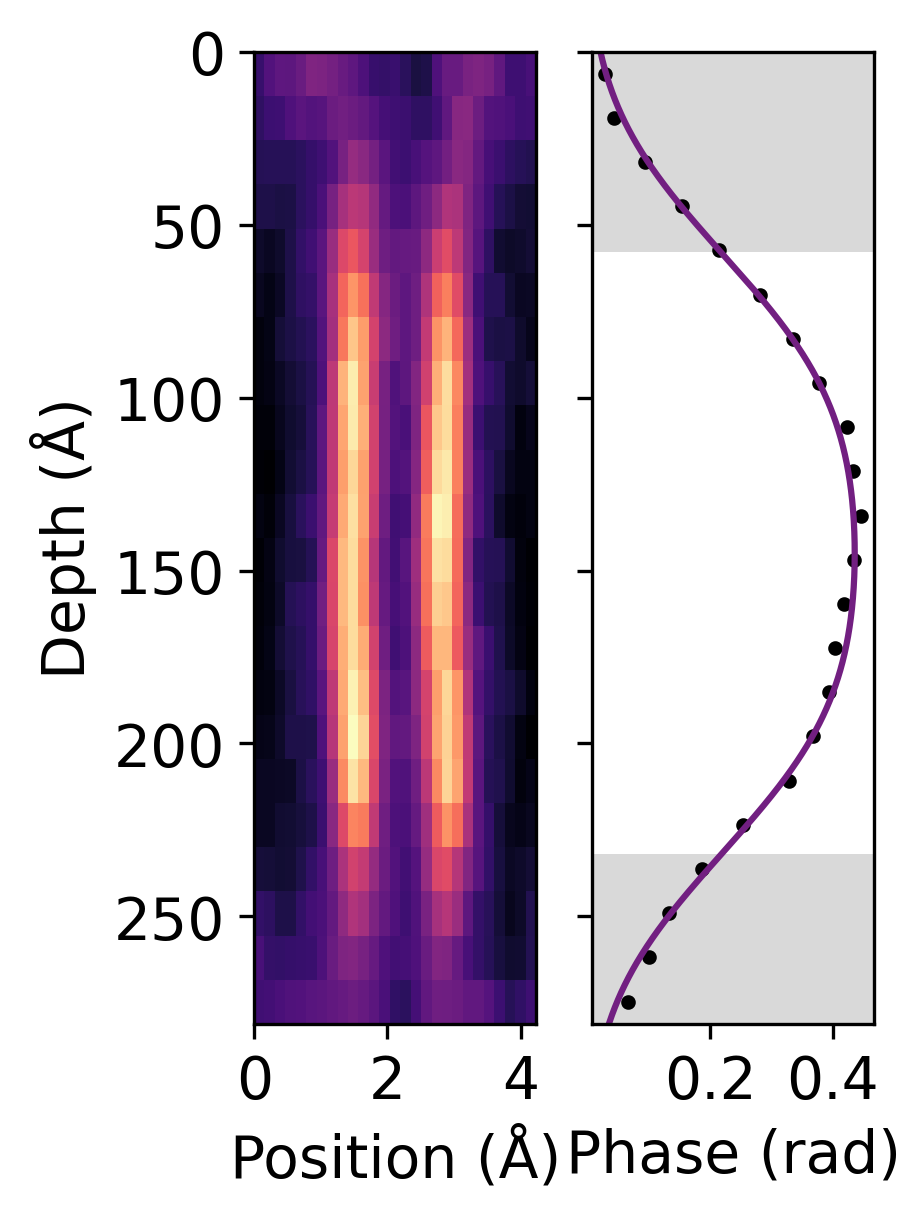

In [29]:
# ── 좌: 단면(cross-section) / 우: column phase profile ──────────────────
#    + 우패널에서 half-max 바깥(비정질) 영역을 회색으로 음영 처리
KEY   = '5V'
PICK  = 75

FIGSIZE2  = (2.6, 4)
WSPACE    = 0.2
MARGIN    = dict(left=0.19, right=0.985, bottom=0.16, top=0.97)

LINE_COL  = 70              # 열 (고정)   ← ROI 좌표계
LINE_ROW  = (48, 74)        # 행 (범위)

SHADE_KW  = dict(color='0.85', lw=0, zorder=0)   # 비정질 영역 배경색
NT        = 4001            # half-max 교차점 탐색용 곡선 샘플링 수

dz = DZ[KEY]
dx = DX[KEY]
NZ = phases[KEY].shape[-1]
T  = NZ * dz

# ── 좌패널 데이터: 단면 재계산 ─────────────────────────────────────
(xi, xf), (yi, yf) = thickness_rois[KEY]
arr = phases[KEY][yi:yf, xi:xf]

r0, r1 = LINE_ROW
n = int(np.hypot(0, r1 - r0)) + 1
L = n * dx

col_line = np.linspace(LINE_COL, LINE_COL, n)
row_line = np.linspace(r0, r1, n)
zs = np.arange(NZ)

rr, zz = np.meshgrid(row_line, zs, indexing="xy")
cc, _  = np.meshgrid(col_line, zs, indexing="xy")

cross_section = map_coordinates(arr, [rr, cc, zz], order=1, mode="nearest")

# ── 우패널 데이터: 단일 column fit 재계산 ──────────────────────────
gid  = roi_indices[KEY][0][0][PICK]
prof = np.asarray(column_lists[KEY])[gid]
k    = np.arange(len(prof))

assert len(prof) == NZ, f'{KEY}: 프로파일 {len(prof)}점 != 슬라이스 {NZ}개'

popt_c, perr_c, _ = fit(
    double_erf, k, prof, plot=False,
    p0=[0.1,  0.3,  4, 13],
    maxfev=10000
    )

# ── half-maximum 두 지점: fit 곡선에서 직접 산출 ───────────────────
t      = np.linspace(-0.5, NZ - 0.5, NT)
curve  = double_erf(t, *popt_c)
p_half = curve.max() / 2.0

sgn = np.sign(curve - p_half)
xs  = np.where(np.diff(sgn) != 0)[0]

z_half = []
for i in xs:
    t0, t1 = t[i], t[i+1]
    c0, c1 = curve[i], curve[i+1]
    tc = t0 if c1 == c0 else t0 + (p_half - c0) * (t1 - t0) / (c1 - c0)
    z_half.append((tc + 0.5) * dz)
z_half = np.array(z_half)

print(f'{KEY}  ROI #{PICK} (전체 #{gid})')
print(f'  max(phase) = {curve.max():.4f} rad,  half = {p_half:.4f} rad')
for j, zh in enumerate(z_half):
    print(f'  half-max #{j}: depth = {zh:7.2f} Å')
if len(z_half) == 2:
    print(f'  상부 a-Si {z_half[0]:6.2f} | c-Si {z_half[1]-z_half[0]:6.2f} | '
          f'하부 a-Si {T - z_half[1]:6.2f} Å   (합 {T:.2f})')

# ── 작도 ───────────────────────────────────────────────────────────
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=FIGSIZE2, dpi=DPI,
    sharey=True, gridspec_kw=dict(wspace=WSPACE)
    )
fig.subplots_adjust(**MARGIN)

axL.imshow(cross_section, aspect="auto", cmap='magma', extent=[0, L, T, 0])
axL.set_xlabel("Position (Å)", fontsize=FONT)
axL.set_ylabel("Depth (Å)", fontsize=FONT)
axL.xaxis.set_major_locator(MaxNLocator(nbins=3, integer=True))

depth = (k + 0.5) * dz
axR.plot(prof, depth, 'k.', ms=5)
xlim = axR.get_xlim()

axR.plot(curve, (t + 0.5) * dz, color=plt.cm.magma(1/3), lw=1.5)

if len(z_half) == 2:                 # ← half-max 바깥 두 영역 음영
    axR.axhspan(0, z_half[0], **SHADE_KW)
    axR.axhspan(z_half[1], T, **SHADE_KW)

axR.set_xlim(xlim)
axR.set_xlabel("Phase (rad)", fontsize=FONT)
axR.xaxis.set_major_locator(MaxNLocator(nbins=3))
axR.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

axL.set_ylim(T, 0)
for ax in (axL, axR):
    ax.tick_params(labelsize=FONT)

plt.show()